In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [5]:
# 1. Read CSV file

df = pd.read_csv("bengaluru_house_prices.csv")
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [11]:
df.sample()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
2562,Plot Area,Ready To Move,Mathikere,3 Bedroom,NaN,1550,2.0,1.0,150.0


In [9]:
df.tail()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.0
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.0
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.0
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.0
13319,Super built-up Area,Ready To Move,Doddathoguru,1 BHK,NaN,550,1.0,1.0,17.0


In [7]:
# Exploratory Data Analysis (EDA)

df.info()
print(df.shape)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB
(13320, 9)


In [8]:
# 2. Check for missing values

df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [12]:
# Correcting the columnm total_sqft

def to_sqft(x):
    try:
        return float(x)
    except:
        parts = str(x).split('-')
        if len(parts) == 2:
            try:
                return (float(parts[0]) + float(parts[1]))
            except:
                return np.nan
        return np.nan

In [14]:
new_df = df[['total_sqft', 'bath', 'balcony', 'price']].copy()
new_df['total_sqft'] = new_df['total_sqft'].apply(to_sqft)
new_df.isnull().sum()

total_sqft     46
bath           73
balcony       609
price           0
dtype: int64

In [15]:
# 3. Separate X and Y

X = new_df[['total_sqft', 'bath', 'balcony']]
y = new_df['price']

In [16]:
# 4. Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(10656, 3)
(2664, 3)
(10656,)
(2664,)


In [19]:
# 5. Fill missing values using median

# find the median of each column from train data
total_sqft_median = X_train['total_sqft'].median()
bath_median = X_train['bath'].median()
balcony_median = X_train['balcony'].median()

In [21]:
# fill missing values in train data
X_train['total_sqft'] = X_train['total_sqft'].fillna(total_sqft_median)
X_train['bath'] = X_train['bath'].fillna(bath_median)
X_train['balcony'] = X_train['balcony'].fillna(balcony_median)

In [22]:
# fill missing values in test data (use the same train medians)
X_test['total_sqft'] = X_test['total_sqft'].fillna(total_sqft_median)
X_test['bath'] = X_test['bath'].fillna(bath_median)
X_test['balcony'] = X_test['balcony'].fillna(balcony_median)

In [23]:
# 6. Check missing values again

print(X_train.isnull().sum())
print(X_test.isnull().sum())

total_sqft    0
bath          0
balcony       0
dtype: int64
total_sqft    0
bath          0
balcony       0
dtype: int64


In [25]:
# 7. Create model

model = LinearRegression()
model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [26]:
# 8. Train model

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [31]:
# 9. Prediction
y_pred = model.predict(X_test)

new_y_pred = np.round(y_pred, 2)
result = pd.DataFrame({'Actual Price': y_test.values, 'Predicted Price': new_y_pred})
result.head(10)

,Actual Price,Predicted Price
0,64.8,62.47
1,125.0,126.30
2,60.0,64.78
3,110.0,140.08
4,210.0,160.53
5,90.0,75.20
6,65.0,74.02
7,35.0,46.25
8,48.0,126.73
9,49.0,69.78


In [32]:
# 10. Print coefficient and intercepts
print("Coefficients:", dict(zip(X.columns, model.coef_)))
print("Intercept:", model.intercept_)

Coefficients: {'total_sqft': np.float64(0.04631944104095342), 'bath': np.float64(34.188769570637504), 'balcony': np.float64(2.2867336313642195)}
Intercept: -56.83375286752914


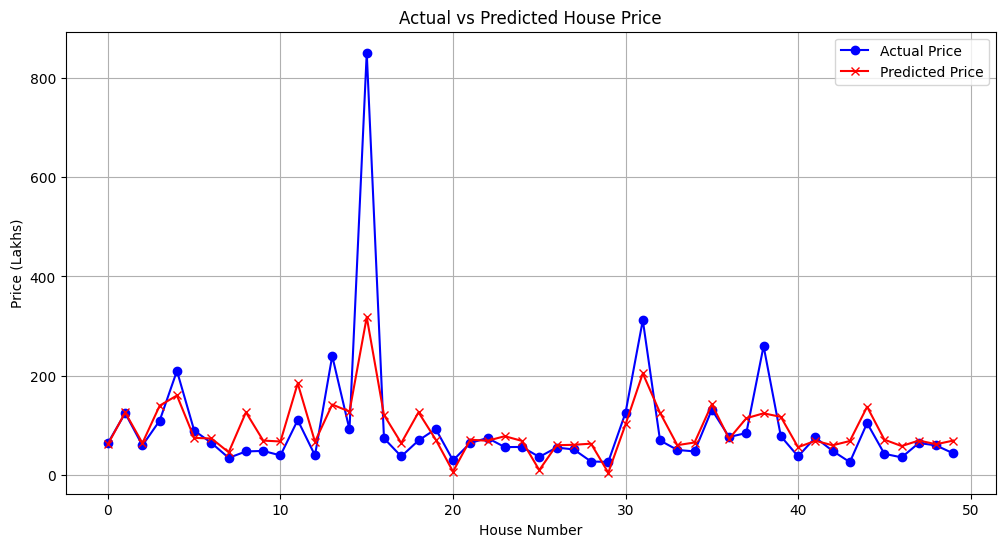

In [36]:
# 11. Actual vs Predicted Chart

plt.figure(figsize=(12, 6))

plt.plot(y_test.values[:50], color='blue', marker='o', label='Actual Price')
plt.plot(y_pred[:50], color='red', marker='x', label='Predicted Price')

plt.xlabel('House Number')
plt.ylabel('Price (Lakhs)')
plt.title('Actual vs Predicted House Price')
plt.legend()
plt.grid(True)
plt.show()

In [34]:
# Model Score
print('R2 score:', r2_score(y_test, y_pred))

R2 score: 0.47582101011355704


In [35]:
new_house = pd.DataFrame({'total_sqft': [1500], 'bath': [2], 'balcony': [1]})
print("Predicted price (Lakhs):", model.predict(new_house)[0])

Predicted price (Lakhs): 83.30968146654024
